<h1 style="font-size:48px; text-align:center;"> Hefmechanisme: analyse</h1>

<div style="max-width: 50%; margin-left: 0; text-align: left;">
<img src="Images/hefmech.png" width="1200">

Dit mechanisme wordt gebruikt in hoogwerkers om werknemers omhoog te heffen met behulp van een hydraulische zuiger. Het vertaalt een kleine verplaatsing van de zuiger in een veel grotere verticale verplaatsing van het bovenste platform.
De constructie is zodanig ontworpen dat het bovenste deel horizontaal blijft tijdens de volledige beweging.

<img src="Images/nacelle_élévatrice.webp" width="1200">

Zonder zuiger, en in verkleinde vorm, kan dit mechanisme bijvoorbeeld worden toegepast in een lampconstructie. Het maakt het mogelijk om een lamp eenvoudig omhoog te brengen zonder dat de richting verandert, en zonder de ruimte‑inname van een klassieke schaarlift. Dit is bijvoorbeeld nuttig bij een chirurgische lamp.

Hetzelfde principe zou ook kunnen worden gebruikt in exoskeletten, waar een compacte, lichte en koersversterkende beweging gewenst is.

<img src="Images/exosquelet.png" width="1200">
</div>

<video width="640" height="360" controls>
  <source src="Images/hef_video.mp4" type="video/mp4">
  Votre navigateur ne supporte pas la lecture vidéo.
</video>

<div style="max-width: 50%; margin-left: 0; text-align: left;">
Om ervoor te zorgen dat het bovenste deel horizontaal blijft, moeten verschillende voorwaarden worden gerespecteerd. De belangrijkste relatie is:

den = np.sin(2*deg45) - 4*np.cos(deg45) + 4
num = np.sin(2*deg45) + 4*np.cos(deg45) - 2*np.cos(2*deg45) - 2

r4l = r6l * num / den

Afhankelijk van de gewenste configuratie kunnen r1, r2 en deg45 vrij worden gekozen.

In het document hemechanisme_keuze_deg45.ipynb wordt de hoek van staaf 1 bepaald zodat het hefmechanisme zo hoog mogelijk kan opklappen zonder over het dode punt te gaan. De optimale hoek bedraagt ongeveer 65°.
Dit is een cruciale keuze in het bewegingstraject, omdat ze toelaat de lengtes van de staven 2, 4, 6 en 8 maximaal te benutten.
</div>

COMMENT: de relatie kan vm duidelijk opgeschreven worden, of tenminste mooier

<div style="max-width: 700px; margin: 0 auto; text-align: justify;">

<h3>Kinematica van het mechanisme </h3>
De belangrijkste bibliotheken worden geïmporteerd, de lengtes van de staven worden gedefinieerd en de invoerbeweging wordt geïnitialiseerd. Vervolgens worden de sluitvergelijkingen opgesteld die specifiek zijn voor dit mechanisme. Voor alle relevante hoeken moeten positie, snelheid en versnelling worden berekend.

<img src="Images/hef_namen.png" width="1200">

De uitrekking van de zuiger r3 vormt de drijvende beweging van het systeem en volgt een minimum‑jerk‑traject voor een heen‑ en teruggaande beweging van de driver.
Er wordt een formule opgesteld die ervoor zorgt dat het systeem niet voorbij het dode punt kan gaan, door de maximale lengte van de zuiger te begrenzen.

Het overschrijden van het dode punt is theoretisch mogelijk, maar zou een ernstig probleem vormen: het bovenste deel zou dan niet langer horizontaal blijven, en bovendien zou de zuiger het mechanisme niet meer binnen zijn werkingsgebied kunnen terugtrekken.

Er wordt gecontroleerd of de hoeken $\phi_7$ en $\phi_{11}$ constant blijven, aangezien dit het verwachte gedrag van het mechanisme is.
</div>

COMMENT: in de volgende code moet waarschijnlijk van hefmechanisme_keuze_deg45 gekopieerd worden

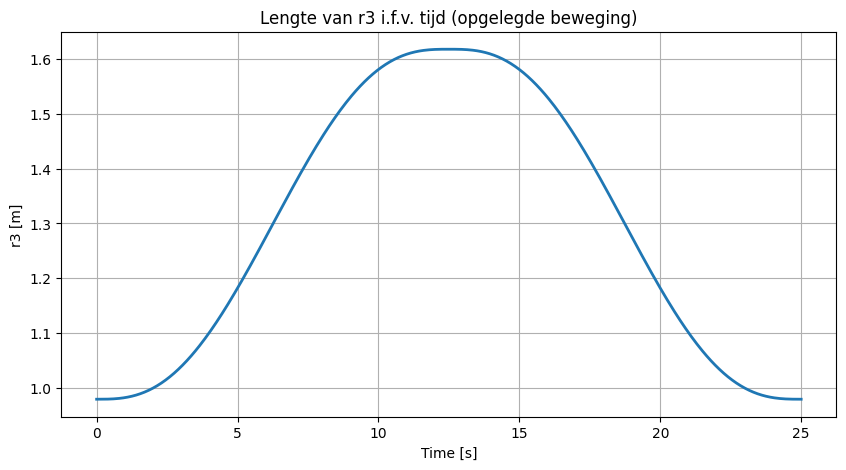

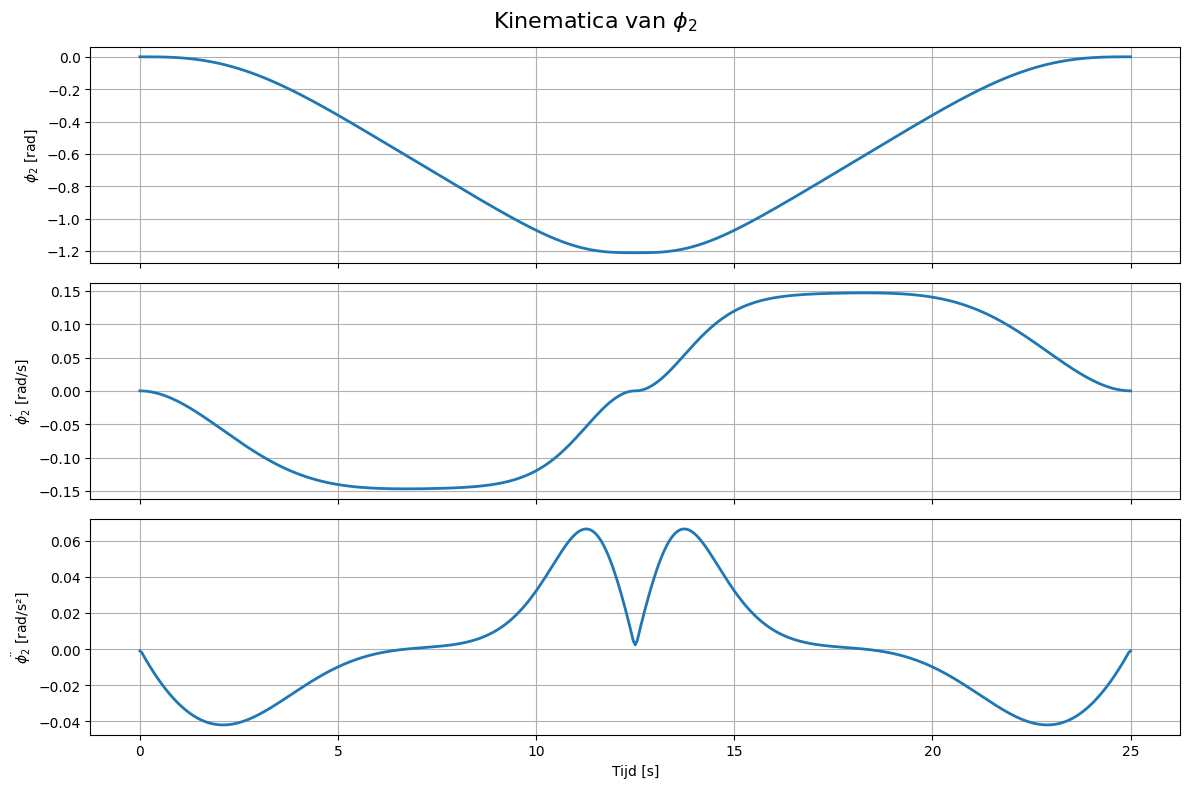

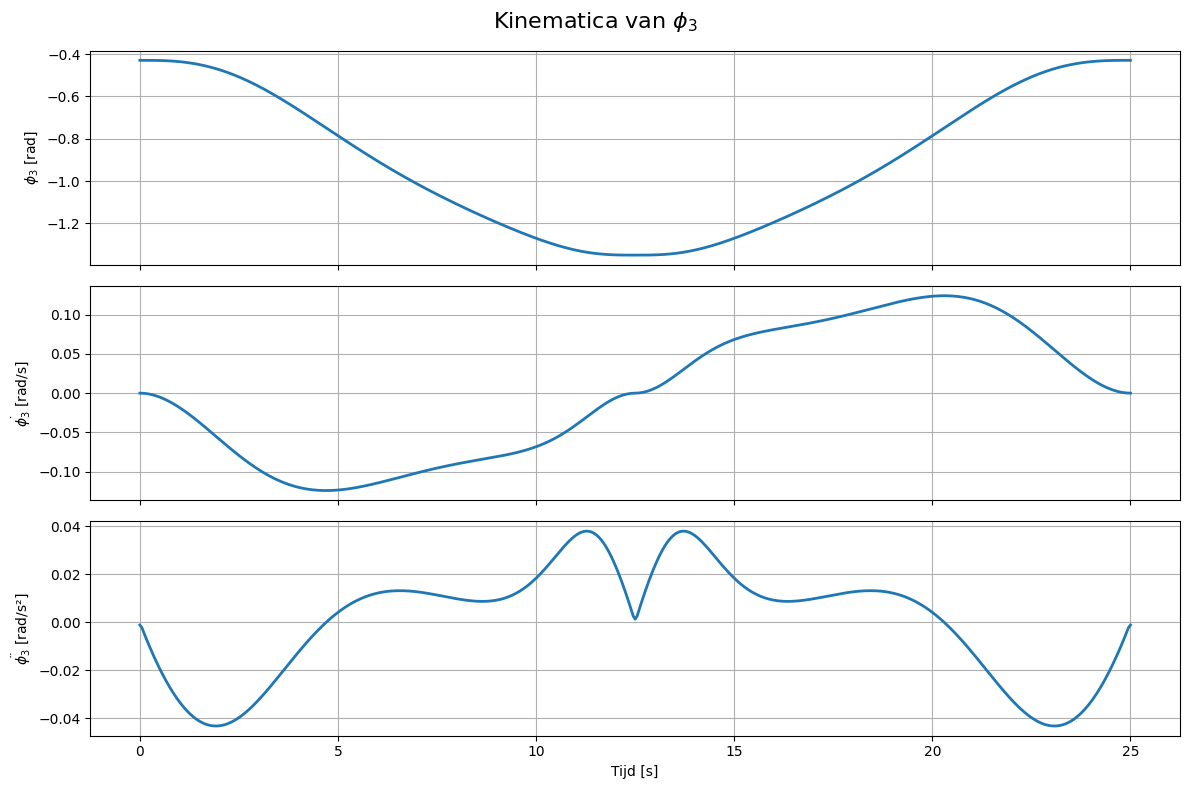

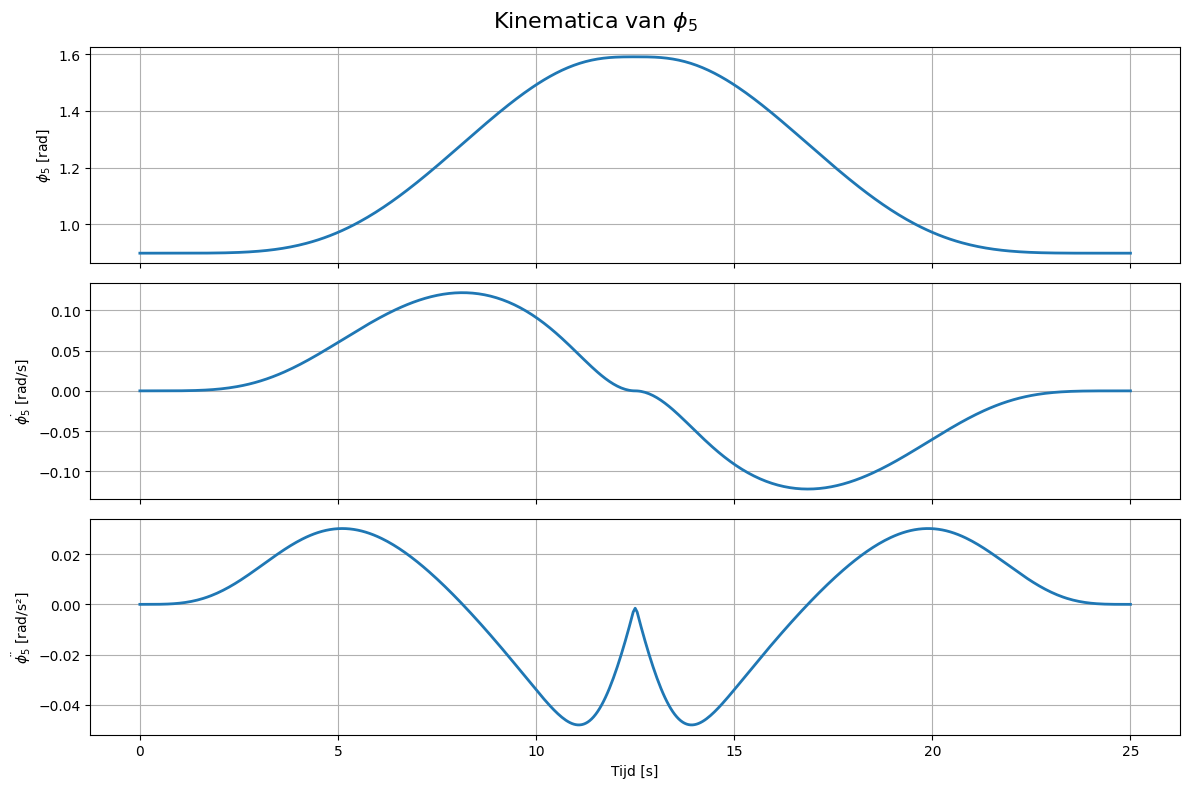

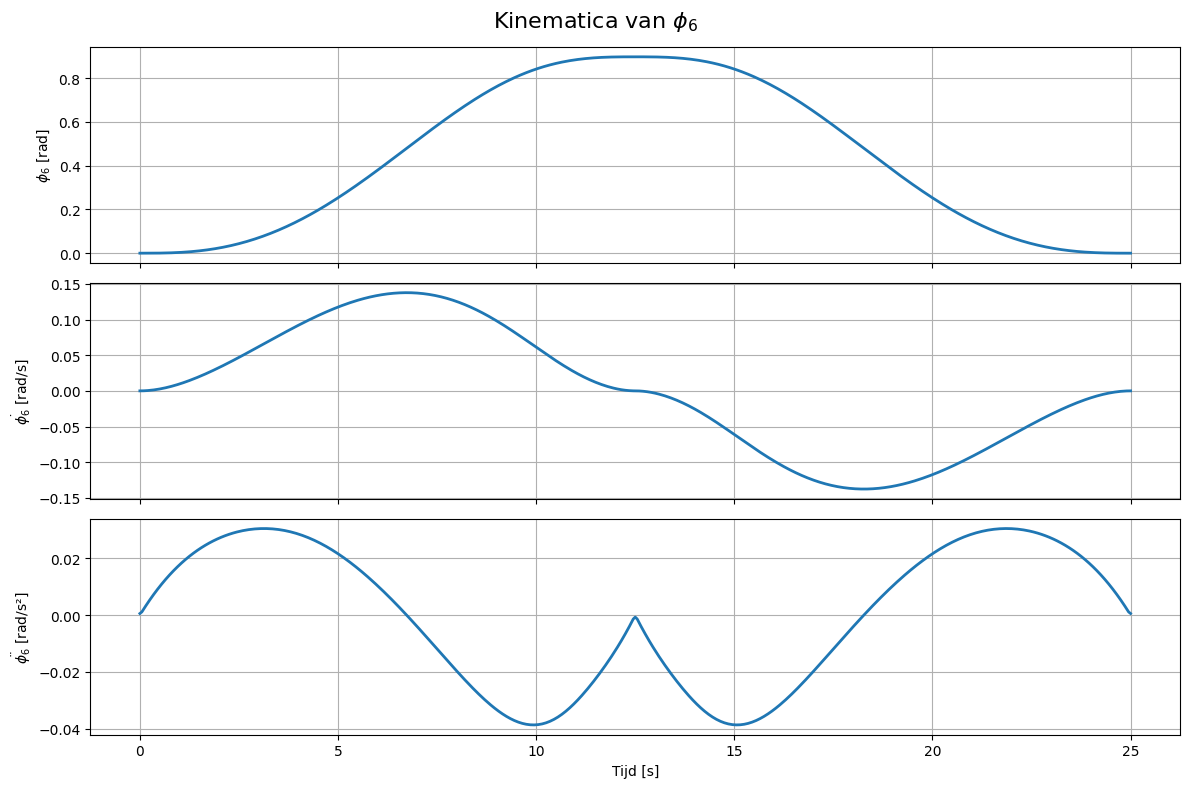

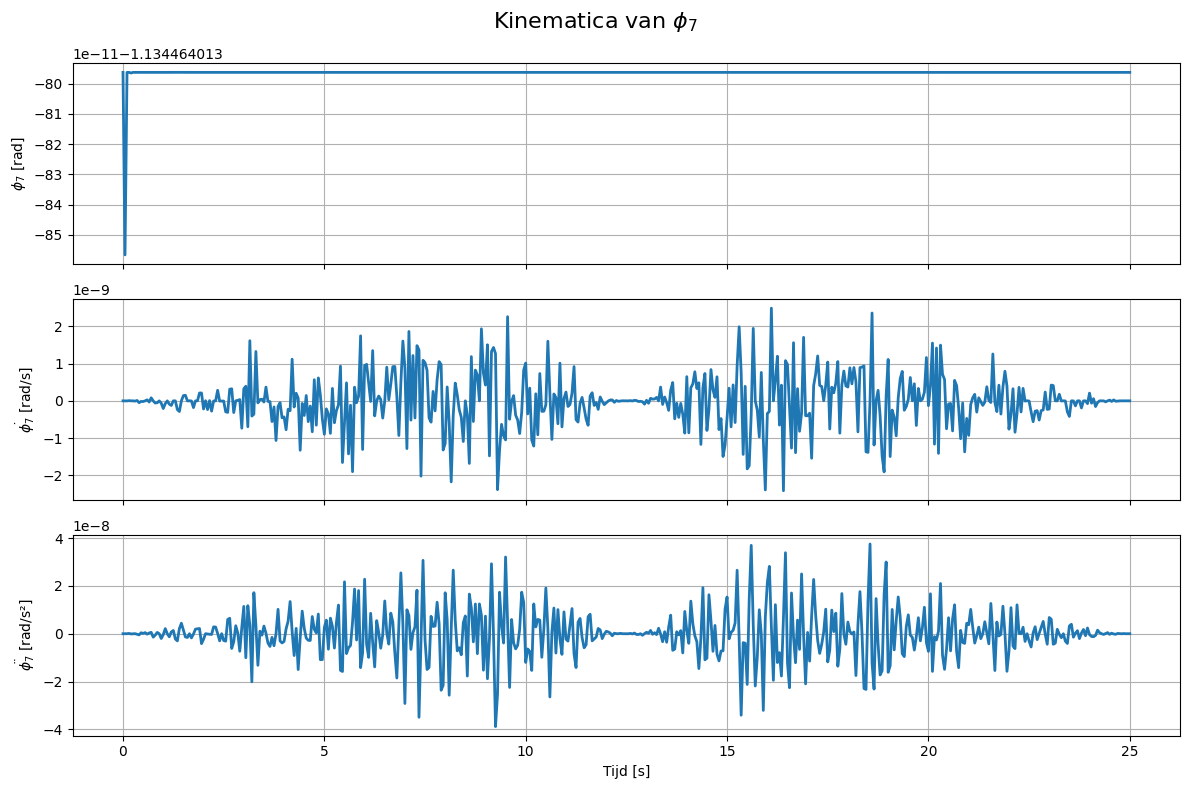

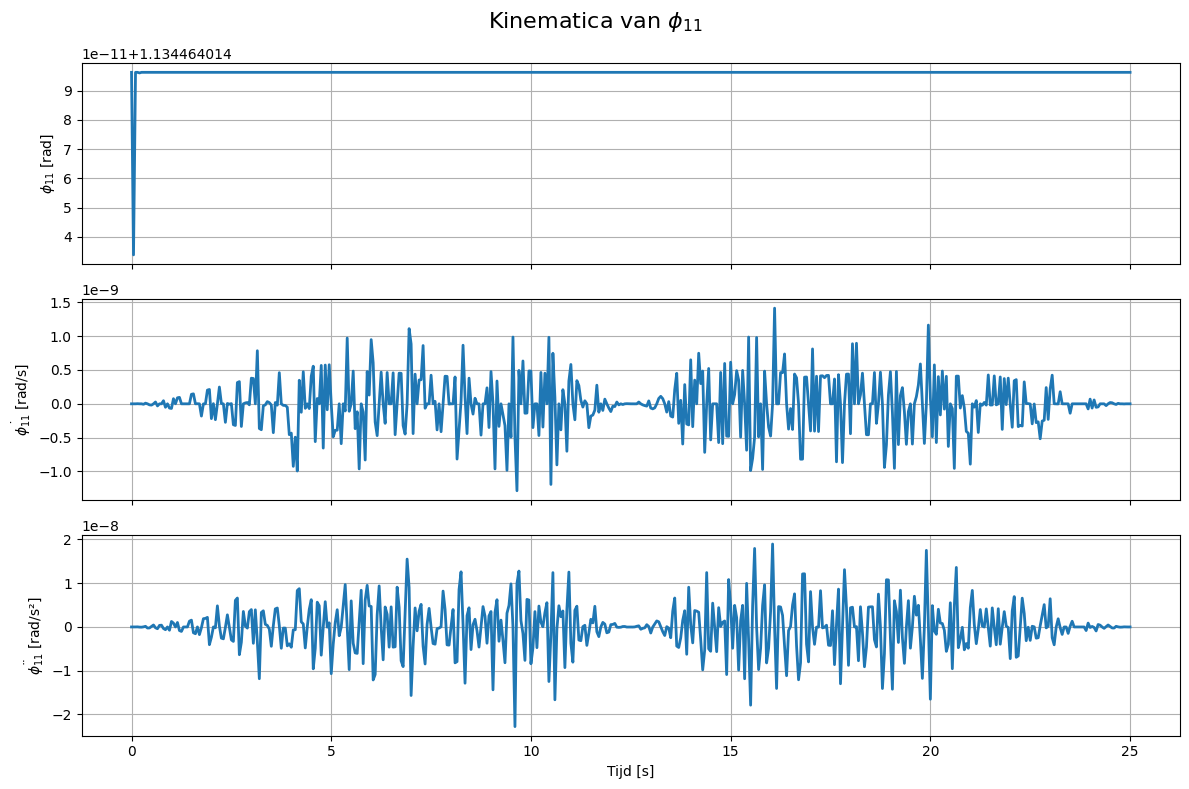

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
# ==========================================================
# PARAMETERS 
# ==========================================================

deg45  = np.deg2rad(65)

# wijzigbare lengtes
r2 = 1.00       
r1 = 0.3

# belangrijkste afhankelijkheden (niet wijzigen)
r4r = r2
r6l = r1

r11 = r1
r7  = r1

# ==========================================================
# r4 hangt af van r2 via r6l en r4r
# ==========================================================

den = np.sin(2*deg45) - 4*np.cos(deg45) + 4
num = np.sin(2*deg45) + 4*np.cos(deg45) - 2*np.cos(2*deg45) - 2

r4l = r6l * num / den
r4  = r4r + r4l

# ==========================================================
# r8 et r6 hangen af van r2
# ==========================================================

r8  = r2 + 2*r11*np.cos(deg45)
r6r = r8 - r6l
r6  = r6l + r6r

# ==========================================================
# r9 hangt af van r11/r7
# ==========================================================

r9r = 1.5 * r11
r9l = r7 #= r1
r9  = r9r + r9l

phi9_offset = -2 * deg45

# ==========================================================
# r5 en r3 initialisatie (variabele lengtes)
# ==========================================================

h_EF = (r9r - r11/2) * np.sin(deg45)

r5 = np.sqrt(
    (r4 - r6r)**2
    + h_EF**2
)

# ==========================================================
# POSITIE VAN PUNTEN A, B, C (vaste punten)
# ==========================================================

A = np.array([0.0, 0.0])
C = A + r1*np.array([np.cos(deg45), np.sin(deg45)])
B = (A + C) / 2

# ==========================================================
# OORSPRONKELIJKE HOEKEN
# ==========================================================

phi2_init  = 0.0
phi4_init  = 0.0
phi6_init  = 0.0
phi8_init  = 0.0

phi7_init  = -deg45
phi11_init = deg45

phi5_init = np.arctan2(
    h_EF,
    r4 - r6r
)

r3_init = np.sqrt(
    (r6r - r11/2*np.cos(deg45))**2
    + (1.5*r11*np.sin(deg45))**2
)

phi3_init = -np.arctan2(
    1.5*r11*np.sin(deg45),
    r6r - r11/2*np.cos(deg45)
)

# ==========================================================
# TIJD
# ==========================================================

t_begin = 0.0
t_end   = 25.0
Ts      = 0.05

t = np.arange(t_begin, t_end + Ts, Ts)
N = len(t)


# ==========================================================
# OPGELEGDE BEWEGING r3(t)
# ==========================================================

r3_max = np.sqrt((r5 + r4 - r1/2*np.cos(2*deg45))**2 + (r1/2*np.sin(2*deg45))**2)
dx = r3_max - r3_init
T = t_end - t_begin

def quintic_out_and_back(t, x0, dx, T):
    x = np.zeros_like(t, dtype=float)
    v = np.zeros_like(t, dtype=float)
    a = np.zeros_like(t, dtype=float)

    mask1 = (t >= 0) & (t <= T)
    tau1 = t[mask1] / T

    s1  = 10*tau1**3 - 15*tau1**4 + 6*tau1**5
    ds1 = 30*tau1**2 - 60*tau1**3 + 30*tau1**4
    dds1 = 60*tau1 - 180*tau1**2 + 120*tau1**3

    x[mask1] = x0 + dx*s1
    v[mask1] = dx/T * ds1
    a[mask1] = dx/T**2 * dds1

    mask2 = (t > T) & (t <= 2*T)
    tau2 = (t[mask2] - T) / T

    s2  = 10*tau2**3 - 15*tau2**4 + 6*tau2**5
    ds2 = 30*tau2**2 - 60*tau2**3 + 30*tau2**4
    dds2 = 60*tau2 - 180*tau2**2 + 120*tau2**3

    x[mask2] = x0 + dx*(1 - s2)
    v[mask2] = -dx/T * ds2
    a[mask2] = -dx/T**2 * dds2

    x[t < 0] = x0
    x[t > 2*T] = x0

    return x, v, a


r3, dr3, ddr3 = quintic_out_and_back(t, r3_init, dx, T/2)

# ==========================================================
# PLOT r3(t)
# ==========================================================

plt.figure(figsize=(10, 5))
plt.plot(t, r3, linewidth=2)
plt.xlabel("Time [s]")
plt.ylabel("r3 [m]")
plt.title("Lengte van r3 i.f.v. tijd (opgelegde beweging)")
plt.grid(True)
plt.show()

# ==========================================================
# HELPERS
# ==========================================================

def unit(phi):
    return np.array([np.cos(phi), np.sin(phi)])

# ==========================================================
# SYSTEEM
#
# Onbekenden:
# phi2, phi3, phi4, phi5, phi6, phi7, phi8, phi11
#
# phi9 is niet constant:
# phi9 = phi11 + phi9_offset
# ==========================================================

def system_equations(x, r3_k):

    phi2, phi3, phi4, phi5, phi6, phi7, phi8, phi11 = x

    phi9 = phi11 + phi9_offset

    # r4 : E/D -> C
    D = C - r4r * unit(phi4)
    E = C - r4  * unit(phi4)

    # r3 : F -> B
    F = B - r3_k * unit(phi3)

    # r11 : K -> D
    K = D - r11 * unit(phi11)
    M11 = D - (r11/2) * unit(phi11)

    # r9 : I/J -> M11
    J = M11 - r9r * unit(phi9)
    I = M11 - r9  * unit(phi9)

    # r6 : J -> F -> G
    G = J + (r6l + r6r) * unit(phi6)

    # r7 : H -> G
    H = G - r7 * unit(phi7)

    # Closures
    eq_EF = F - (E + r5 * unit(phi5))
    eq_KA = A - (K + r2 * unit(phi2))
    eq_JF = F - (J + r6l * unit(phi6))
    eq_HI = I - (H - r8 * unit(phi8))

    return np.concatenate([eq_EF, eq_KA, eq_JF, eq_HI])

# ==========================================================
# POSITIES OPLOSSEN
# ==========================================================

phi2  = np.zeros(N)
phi3  = np.zeros(N)
phi4  = np.zeros(N)
phi5  = np.zeros(N)
phi6  = np.zeros(N)
phi7  = np.zeros(N)
phi8  = np.zeros(N)
phi11 = np.zeros(N)

x_guess = np.array([
    phi2_init,
    phi3_init,
    phi4_init,
    phi5_init,
    phi6_init,
    phi7_init,
    phi8_init,
    phi11_init
])

for k in range(N):

    sol, info, ier, msg = fsolve(
        lambda x: system_equations(x, r3[k]),
        x_guess,
        full_output=True,
        maxfev=3000
    )

    residual = np.linalg.norm(system_equations(sol, r3[k]))

    if ier != 1 and residual > 1e-6:
        print(f"Attention convergence frame {k}")
        print(msg)
        print("residual =", residual)

    phi2[k], phi3[k], phi4[k], phi5[k], phi6[k], phi7[k], phi8[k], phi11[k] = sol

    x_guess = sol.copy()

# ==========================================================
# HOEKSNELHEDEN EN HOEKVERSNELLINGEN
# via afgeleide sluitingsvergelijkingen
# ==========================================================

def numerical_jacobian_q(func, q, r3_k, eps=1e-7):
    n = len(q)
    F0 = func(q, r3_k)
    J = np.zeros((len(F0), n))

    for i in range(n):
        q_eps = q.copy()
        q_eps[i] += eps
        F_eps = func(q_eps, r3_k)
        J[:, i] = (F_eps - F0) / eps

    return J


def numerical_jacobian_r3(func, q, r3_k, eps=1e-7):
    F0 = func(q, r3_k)
    F_eps = func(q, r3_k + eps)
    return (F_eps - F0) / eps


# matrix met alle hoeken
Q = np.column_stack([
    phi2,
    phi3,
    phi4,
    phi5,
    phi6,
    phi7,
    phi8,
    phi11
])

# arrays voor snelheden
dphi2  = np.zeros(N)
dphi3  = np.zeros(N)
dphi4  = np.zeros(N)
dphi5  = np.zeros(N)
dphi6  = np.zeros(N)
dphi7  = np.zeros(N)
dphi8  = np.zeros(N)
dphi11 = np.zeros(N)

# arrays voor versnellingen
ddphi2  = np.zeros(N)
ddphi3  = np.zeros(N)
ddphi4  = np.zeros(N)
ddphi5  = np.zeros(N)
ddphi6  = np.zeros(N)
ddphi7  = np.zeros(N)
ddphi8  = np.zeros(N)
ddphi11 = np.zeros(N)

# opslag van J en rechterlid b
J_list = np.zeros((N, 8, 8))
b_list = np.zeros((N, 8))

dQ = np.zeros((N, 8))
ddQ = np.zeros((N, 8))

# ==========================================================
# SNELHEDEN
#
# F(q, r3) = 0
# dF/dq * qdot + dF/dr3 * r3dot = 0
#
# J * qdot = -Fr * dr3
# ==========================================================

for k in range(N):

    q_k = Q[k, :]

    J = numerical_jacobian_q(system_equations, q_k, r3[k])
    Fr = numerical_jacobian_r3(system_equations, q_k, r3[k])

    b = -Fr * dr3[k]

    qdot = np.linalg.solve(J, b)

    J_list[k, :, :] = J
    b_list[k, :] = b
    dQ[k, :] = qdot

# ==========================================================
# VERSNELLINGEN
#
# J*qdot = b
# d/dt(J*qdot) = d/dt(b)
# J*qddot + Jdot*qdot = bdot
#
# J*qddot = bdot - Jdot*qdot
# ==========================================================

Jdot_list = np.gradient(J_list, Ts, axis=0)
bdot_list = np.gradient(b_list, Ts, axis=0)

for k in range(N):

    J = J_list[k, :, :]
    Jdot = Jdot_list[k, :, :]
    bdot = bdot_list[k, :]

    qdot = dQ[k, :]

    rhs_a = bdot - Jdot @ qdot

    qddot = np.linalg.solve(J, rhs_a)

    ddQ[k, :] = qddot

# uitschrijven naar aparte variabelen
dphi2  = dQ[:, 0]
dphi3  = dQ[:, 1]
dphi4  = dQ[:, 2]
dphi5  = dQ[:, 3]
dphi6  = dQ[:, 4]
dphi7  = dQ[:, 5]
dphi8  = dQ[:, 6]
dphi11 = dQ[:, 7]

ddphi2  = ddQ[:, 0]
ddphi3  = ddQ[:, 1]
ddphi4  = ddQ[:, 2]
ddphi5  = ddQ[:, 3]
ddphi6  = ddQ[:, 4]
ddphi7  = ddQ[:, 5]
ddphi8  = ddQ[:, 6]
ddphi11 = ddQ[:, 7]

# ==========================================================
# MECHANISM POINTS
# ==========================================================

def mechanism_points(k):

    phi9 = phi11[k] + phi9_offset

    D = C - r4r * unit(phi4[k])
    E = C - r4  * unit(phi4[k])

    F = B - r3[k] * unit(phi3[k])

    K = D - r11 * unit(phi11[k])
    M11 = D - (r11/2) * unit(phi11[k])

    J = M11 - r9r * unit(phi9)
    I = M11 - r9  * unit(phi9)

    G = J + (r6l + r6r) * unit(phi6[k])
    H = G - r7 * unit(phi7[k])

    return A, B, C, D, E, F, G, H, I, J, K, M11

# ==========================================================
# ANIMATIE
# ==========================================================

plt.ioff()

fig, ax = plt.subplots(figsize=(9, 7))

index_vec = np.arange(0, N, 5, dtype=int)

x_left   = -2
x_right  =  1
y_bottom = -0.1
y_top    =  2.4

def update(frame_idx):

    k = index_vec[frame_idx]

    ax.clear()
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(x_left, x_right)
    ax.set_ylim(y_bottom, y_top)
    ax.grid(True)

    ax.set_xlabel("[m]")
    ax.set_ylabel("[m]")
    ax.set_title(f"Positions - frame {k} - t = {t[k]:.2f} s")

    A_, B_, C_, D, E, F, G, H, I, J, K, M11 = mechanism_points(k)

    ax.plot([A_[0], B_[0], C_[0]],
            [A_[1], B_[1], C_[1]],
            "-o", linewidth=3, label="r1")

    ax.plot([B_[0], F[0]],
            [B_[1], F[1]],
            "-o", linewidth=2, label="r3")

    ax.plot([C_[0], D[0], E[0]],
            [C_[1], D[1], E[1]],
            "-o", linewidth=2, label="r4l + r4r")

    ax.plot([E[0], F[0]],
            [E[1], F[1]],
            "-o", linewidth=2, label="r5")

    ax.plot([K[0], A_[0]],
            [K[1], A_[1]],
            "-o", linewidth=2, label="r2")

    ax.plot([K[0], M11[0], D[0]],
            [K[1], M11[1], D[1]],
            "-o", linewidth=2, label="r11")

    ax.plot([M11[0], J[0], I[0]],
            [M11[1], J[1], I[1]],
            "-o", linewidth=2, label="r9l + r9r")

    ax.plot([J[0], F[0], G[0]],
            [J[1], F[1], G[1]],
            "-o", linewidth=2, label="r6")

    # r7 : H -> G
    ax.plot(
        [H[0], G[0]],
        [H[1], G[1]],
        "-o",
        linewidth=2,
        label="r7"
    )

    # r8 : I -> H
    ax.plot(
        [I[0], H[0]],
        [I[1], H[1]],
        "-o",
        linewidth=2,
        label="r8"
    )

    points = {
        "A": A_,
        "B": B_,
        "C": C_,
        "D": D,
        "E": E,
        "F": F,
        "G": G,
        "H": H,
        "I": I,
        "J": J,
        "K": K
    }

    for name, point in points.items():
        ax.text(point[0] + 0.02, point[1] + 0.02, name, fontsize=10)

    ax.legend(loc="upper right", fontsize=8)

    return []

ani = FuncAnimation(
    fig,
    update,
    frames=len(index_vec),
    interval=50,
    blit=False
)

plt.close(fig)

display(HTML(ani.to_jshtml()))

# ==========================================================
# PLOTS KINEMATICA
# ==========================================================

def plot_kinematics(t, phi, dphi, ddphi, name):
    fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    axs[0].plot(t, phi, linewidth=2)
    axs[0].set_ylabel(fr'${name}$ [rad]')
    axs[0].grid(True)

    axs[1].plot(t, dphi, linewidth=2)
    axs[1].set_ylabel(fr'$\dot{{{name}}}$ [rad/s]')
    axs[1].grid(True)

    axs[2].plot(t, ddphi, linewidth=2)
    axs[2].set_ylabel(fr'$\ddot{{{name}}}$ [rad/s²]')
    axs[2].set_xlabel('Tijd [s]')
    axs[2].grid(True)

    fig.suptitle(fr'Kinematica van ${name}$', fontsize=16)
    plt.tight_layout()
    plt.show()


plot_kinematics(t, phi2,  dphi2,  ddphi2,  r'\phi_2')
plot_kinematics(t, phi3,  dphi3,  ddphi3,  r'\phi_3')
#plot_kinematics(t, phi4,  dphi4,  ddphi4,  r'\phi_4')
plot_kinematics(t, phi5,  dphi5,  ddphi5,  r'\phi_5')
plot_kinematics(t, phi6,  dphi6,  ddphi6,  r'\phi_6')
plot_kinematics(t, phi7,  dphi7,  ddphi7,  r'\phi_7')
#plot_kinematics(t, phi8,  dphi8,  ddphi8,  r'\phi_8')
plot_kinematics(t, phi11, dphi11, ddphi11, r'\phi_{11}')  #9 beweegt met ph11

<div style="max-width: 700px; margin: 0 auto; text-align: justify;">

<h3>Kinematica van de punten</h3>
In dit onderdeel worden de snelheden en versnellingen van de punten van het mechanisme berekend.
Als controle wordt het verschil tussen de horizontale en verticale snelheden van de punten G en H geëvalueerd, om te verifiëren dat de berekende snelheden overeenkomen met wat in de animatie wordt waargenomen — namelijk dat staaf 7 horizontaal blijft.
Deze verschillen liggen in de grootteorde van de machineprecisie en zijn dus effectief nul.
</div>

comment: 'grootteorde van de machineprecisie' is fout; deze is 10^-16. beter anders formuleren, zoals 'in de grootteorde van de numerieke precisie'

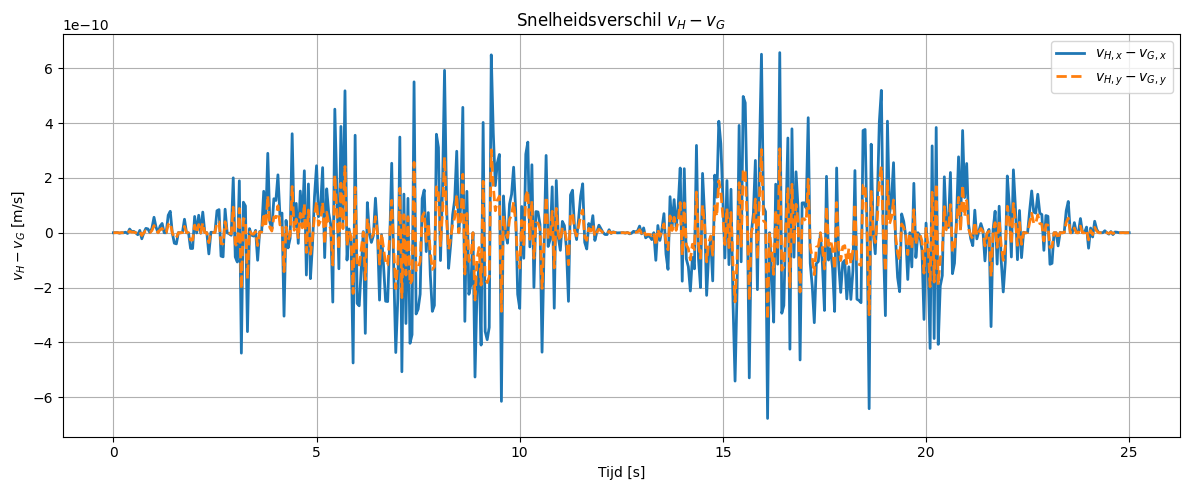

In [14]:
# ==========================================================
# KINEMATICA VAN HET MECHANISME
# ==========================================================

def point_vel_from_bar(v_start, r, phi, dphi, sign=1):
    """
    Point = Start + sign * r * unit(phi)
    """
    return v_start + sign * np.array([
        -r*np.sin(phi)*dphi,
         r*np.cos(phi)*dphi
    ])


def point_acc_from_bar(a_start, r, phi, dphi, ddphi, sign=1):
    """
    Point = Start + sign * r * unit(phi)
    """
    return a_start + sign * np.array([
        -r*np.cos(phi)*dphi**2 - r*np.sin(phi)*ddphi,
        -r*np.sin(phi)*dphi**2 + r*np.cos(phi)*ddphi
    ])


# ==========================================================
# VASTE PUNTEN
# ==========================================================

vA = np.zeros((2, N))
aA = np.zeros((2, N))

vB = np.zeros((2, N))
aB = np.zeros((2, N))

vC = np.zeros((2, N))
aC = np.zeros((2, N))


# ==========================================================
# BEWEGENDE PUNTEN
# Gebuikte geometrische conventies:
#
# D = C - r4r * unit(phi4)
# E = C - r4  * unit(phi4)
# F = B - r3  * unit(phi3)
# K = D - r11 * unit(phi11)
# M11 = D - r11/2 * unit(phi11)
# J = M11 - r9r * unit(phi9)
# I = M11 - r9  * unit(phi9)
# G = J + (r6l+r6r) * unit(phi6)
# H = G - r7 * unit(phi7)
# ==========================================================

vD = np.zeros((2, N))
vE = np.zeros((2, N))
vF = np.zeros((2, N))
vK = np.zeros((2, N))
vM11 = np.zeros((2, N))
vJ = np.zeros((2, N))
vI = np.zeros((2, N))
vG = np.zeros((2, N))
vH = np.zeros((2, N))

aD = np.zeros((2, N))
aE = np.zeros((2, N))
aF = np.zeros((2, N))
aK = np.zeros((2, N))
aM11 = np.zeros((2, N))
aJ = np.zeros((2, N))
aI = np.zeros((2, N))
aG = np.zeros((2, N))
aH = np.zeros((2, N))


for k in range(N):

    # r9 stijf verbonden aan r11
    phi9_k = phi11[k] + phi9_offset
    dphi9_k = dphi11[k]
    ddphi9_k = ddphi11[k]

    # ------------------------------------------------------
    # D = C - r4r * unit(phi4)
    # ------------------------------------------------------
    vD[:, k] = point_vel_from_bar(
        vC[:, k],
        r4r,
        phi4[k],
        dphi4[k],
        sign=-1
    )

    aD[:, k] = point_acc_from_bar(
        aC[:, k],
        r4r,
        phi4[k],
        dphi4[k],
        ddphi4[k],
        sign=-1
    )

    # ------------------------------------------------------
    # E = C - r4 * unit(phi4)
    # ------------------------------------------------------
    vE[:, k] = point_vel_from_bar(
        vC[:, k],
        r4,
        phi4[k],
        dphi4[k],
        sign=-1
    )

    aE[:, k] = point_acc_from_bar(
        aC[:, k],
        r4,
        phi4[k],
        dphi4[k],
        ddphi4[k],
        sign=-1
    )

    # ------------------------------------------------------
    # F = B - r3 * unit(phi3)
    # opgelet : r3 is variabel
    # F = B - r3 [cos(phi3), sin(phi3)]
    # ------------------------------------------------------
    vF[:, k] = vB[:, k] - np.array([
        dr3[k]*np.cos(phi3[k]) - r3[k]*np.sin(phi3[k])*dphi3[k],
        dr3[k]*np.sin(phi3[k]) + r3[k]*np.cos(phi3[k])*dphi3[k]
    ])

    aF[:, k] = aB[:, k] - np.array([
        ddr3[k]*np.cos(phi3[k])
        - 2*dr3[k]*np.sin(phi3[k])*dphi3[k]
        - r3[k]*np.cos(phi3[k])*dphi3[k]**2
        - r3[k]*np.sin(phi3[k])*ddphi3[k],

        ddr3[k]*np.sin(phi3[k])
        + 2*dr3[k]*np.cos(phi3[k])*dphi3[k]
        - r3[k]*np.sin(phi3[k])*dphi3[k]**2
        + r3[k]*np.cos(phi3[k])*ddphi3[k]
    ])

    # ------------------------------------------------------
    # K = D - r11 * unit(phi11)
    # ------------------------------------------------------
    vK[:, k] = point_vel_from_bar(
        vD[:, k],
        r11,
        phi11[k],
        dphi11[k],
        sign=-1
    )

    aK[:, k] = point_acc_from_bar(
        aD[:, k],
        r11,
        phi11[k],
        dphi11[k],
        ddphi11[k],
        sign=-1
    )

    # ------------------------------------------------------
    # M11 = D - r11/2 * unit(phi11)
    # ------------------------------------------------------
    vM11[:, k] = point_vel_from_bar(
        vD[:, k],
        r11/2,
        phi11[k],
        dphi11[k],
        sign=-1
    )

    aM11[:, k] = point_acc_from_bar(
        aD[:, k],
        r11/2,
        phi11[k],
        dphi11[k],
        ddphi11[k],
        sign=-1
    )

    # ------------------------------------------------------
    # J = M11 - r9r * unit(phi9)
    # ------------------------------------------------------
    vJ[:, k] = point_vel_from_bar(
        vM11[:, k],
        r9r,
        phi9_k,
        dphi9_k,
        sign=-1
    )

    aJ[:, k] = point_acc_from_bar(
        aM11[:, k],
        r9r,
        phi9_k,
        dphi9_k,
        ddphi9_k,
        sign=-1
    )

    # ------------------------------------------------------
    # I = M11 - r9 * unit(phi9)
    # ------------------------------------------------------
    vI[:, k] = point_vel_from_bar(
        vM11[:, k],
        r9,
        phi9_k,
        dphi9_k,
        sign=-1
    )

    aI[:, k] = point_acc_from_bar(
        aM11[:, k],
        r9,
        phi9_k,
        dphi9_k,
        ddphi9_k,
        sign=-1
    )

    # ------------------------------------------------------
    # G = J + (r6l+r6r) * unit(phi6)
    # ------------------------------------------------------
    vG[:, k] = point_vel_from_bar(
        vJ[:, k],
        r6l + r6r,
        phi6[k],
        dphi6[k],
        sign=1
    )

    aG[:, k] = point_acc_from_bar(
        aJ[:, k],
        r6l + r6r,
        phi6[k],
        dphi6[k],
        ddphi6[k],
        sign=1
    )

    # ------------------------------------------------------
    # H = G - r7 * unit(phi7)
    # ------------------------------------------------------
    vH[:, k] = point_vel_from_bar(
        vG[:, k],
        r7,
        phi7[k],
        dphi7[k],
        sign=-1
    )

    aH[:, k] = point_acc_from_bar(
        aG[:, k],
        r7,
        phi7[k],
        dphi7[k],
        ddphi7[k],
        sign=-1
    )


# ==========================================================
# CHECK r7 : vH - vG
# ==========================================================

vHG = vH - vG

vHG_norm = np.sqrt(vHG[0, :]**2 + vHG[1, :]**2)

angle_vHG = np.unwrap(np.arctan2(vHG[1, :], vHG[0, :]))

# In theorie, aangezien H = G - r7*unit(phi7),
# vH - vG is loodrecht op r7
# en heeft r7*dphi7 als norm.

plt.figure(figsize=(12, 5))
plt.plot(t, vHG[0, :], linewidth=2, label=r'$v_{H,x} - v_{G,x}$')
plt.plot(t, vHG[1, :], '--', linewidth=2, label=r'$v_{H,y} - v_{G,y}$')
plt.xlabel('Tijd [s]')
plt.ylabel(r'$v_H - v_G$ [m/s]')
plt.title(r'Snelheidsverschil $v_H - v_G$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


<div style="max-width: 700px; margin: 0 auto; text-align: justify;">

<h3>Dynamica van het mechanisme</h3>
In dit onderdeel worden de krachten berekend die in en op het mechanisme werken.

<h4>Krachten in het mechanisme zonder wrijving</h4>
In onderstaande code wordt aangenomen dat alle staven uit aluminium zijn vervaardigd, met een diameter van 1 cm en met het zwaartepunt in het midden van elke staaf. Al deze parameters kunnen naar wens worden aangepast. Ook de waarde van de zwaartekracht kan worden gewijzigd. Voorlopig wordt de wrijving in de glijder verwaarloosd.

</div>

In [19]:
# ==========================================================
# TOOLS + Barlink-KLASSE
# ==========================================================

def cog_kinematics(valA, valB, Cog_parameter):
    return valA * (1 - Cog_parameter) + valB * Cog_parameter


class BarLink:
    def __init__(
        self,
        density,
        diameter,
        length,
        vBegin,
        vEnd,
        aBegin,
        aEnd,
        Cog_parameter,
        intern_joint_position=None,
        angular_velocity=None,
        angular_acceleration=None
    ):
        self.density = density
        self.diameter = diameter
        self.length = length
        self.angular_velocity = angular_velocity
        self.angular_acceleration = angular_acceleration
        self.Cog_parameter = Cog_parameter
        self.intern_joint_position = intern_joint_position

        self.velocity = cog_kinematics(vBegin, vEnd, Cog_parameter)
        self.acceleration = cog_kinematics(aBegin, aEnd, Cog_parameter)

    @property
    def cross_sectional_area(self):
        radius = self.diameter / 2
        return np.pi * radius**2

    @property
    def volume(self):
        return self.cross_sectional_area * self.length

    @property
    def mass(self):
        return self.density * self.volume

    @property
    def distance_Cog_intern_joint(self):
        return self.intern_joint_position - self.Cog_parameter * self.length

    def distance_Cog_joint(self, joint_number):
        if joint_number == 1:
            return self.Cog_parameter * self.length
        elif joint_number == 2:
            return self.length - self.Cog_parameter * self.length

    @property
    def inertia(self):
        return (1/12) * self.mass * self.length**2


def moment_coeffs(phi, s):
    return -s*np.sin(phi), s*np.cos(phi)


def add_force(A_mat, row, var, coef, idx):
    A_mat[row, idx[var]] += coef


def add_moment(A_mat, row, var_x, var_y, phi, s, idx, coef=1.0):
    cx, cy = moment_coeffs(phi, s)
    A_mat[row, idx[var_x]] += coef * cx
    A_mat[row, idx[var_y]] += coef * cy


def add_force_moment(A_mat, row, var, Fx_coef, Fy_coef, phi, s, idx):
    cx, cy = moment_coeffs(phi, s)
    A_mat[row, idx[var]] += cx*Fx_coef + cy*Fy_coef


# ==========================================================
# PARAMETERS MECHANISME
# ==========================================================

densityAL = 2700
diameter = 0.01
g = 9.81
Cog_parameter = 0.5


# ==========================================================
# STAVEN
# ==========================================================

bar_AK = BarLink(
    density=densityAL,
    diameter=diameter,
    length=r2,
    vBegin=vA,
    vEnd=vK,
    aBegin=aA,
    aEnd=aK,
    Cog_parameter=Cog_parameter,
    angular_velocity=dphi2,
    angular_acceleration=ddphi2
)

bar_CDE = BarLink(
    density=densityAL,
    diameter=diameter,
    length=r4,
    vBegin=vC,
    vEnd=vE,
    aBegin=aC,
    aEnd=aE,
    Cog_parameter=Cog_parameter,
    intern_joint_position=r4r,
    angular_velocity=dphi4,
    angular_acceleration=ddphi4
)

bar_KM11D = BarLink(
    density=densityAL,
    diameter=diameter,
    length=r11,
    vBegin=vK,
    vEnd=vD,
    aBegin=aK,
    aEnd=aD,
    Cog_parameter=Cog_parameter,
    intern_joint_position=r11/2,
    angular_velocity=dphi11,
    angular_acceleration=ddphi11
)

bar_M11JI = BarLink(
    density=densityAL,
    diameter=diameter,
    length=r9,
    vBegin=vM11,
    vEnd=vI,
    aBegin=aM11,
    aEnd=aI,
    Cog_parameter=Cog_parameter,
    intern_joint_position=r9r,
    angular_velocity=dphi11,
    angular_acceleration=ddphi11
)

bar_EF = BarLink(
    density=densityAL,
    diameter=diameter,
    length=r5,
    vBegin=vE,
    vEnd=vF,
    aBegin=aE,
    aEnd=aF,
    Cog_parameter=Cog_parameter,
    angular_velocity=dphi5,
    angular_acceleration=ddphi5
)

bar_JFG = BarLink(
    density=densityAL,
    diameter=diameter,
    length=r6l + r6r,
    vBegin=vJ,
    vEnd=vG,
    aBegin=aJ,
    aEnd=aG,
    Cog_parameter=Cog_parameter,
    intern_joint_position=r6l,
    angular_velocity=dphi6,
    angular_acceleration=ddphi6
)

bar_IH = BarLink(
    density=densityAL,
    diameter=diameter,
    length=r8,
    vBegin=vI,
    vEnd=vH,
    aBegin=aI,
    aEnd=aH,
    Cog_parameter=Cog_parameter,
    angular_velocity=dphi8,
    angular_acceleration=ddphi8
)

bar_GH = BarLink(
    density=densityAL,
    diameter=diameter,
    length=r7,
    vBegin=vG,
    vEnd=vH,
    aBegin=aG,
    aEnd=aH,
    Cog_parameter=Cog_parameter,
    angular_velocity=dphi7,
    angular_acceleration=ddphi7
)

<div style="max-width: 700px; margin: 0 auto; text-align: justify;">

<h3>Zuigerkracht met de matrixmethode</h3>
In dit onderdeel wordt de kracht van de zuiger berekend met behulp van de matrixmethode. Daarbij wordt een 24×24‑matrix opgesteld die de kracht- en momentvergelijkingen van het volledige systeem omvat, om uiteindelijk de axiale kracht F_ax3 in de zuiger te bepalen.

</div>

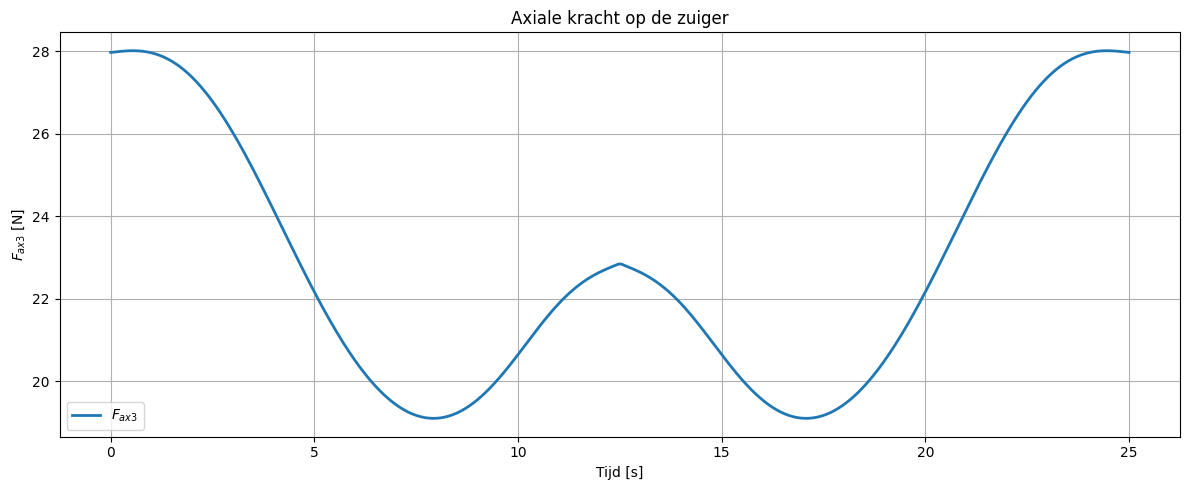

In [21]:
# ==========================================================
# DYNAMICA MET INKLEMMOMENT TUSSEN STAAF 11 EN STAAF 9
#  (VERBETERDE VERSIE) : coherente momenten met begin -> end
# ==========================================================

def add_force_moment(A_mat, row, var, Fx_coef, Fy_coef, phi, s, idx):
    cx, cy = moment_coeffs(phi, s)
    A_mat[row, idx[var]] += cx*Fx_coef + cy*Fy_coef


unknowns = [
    "A_x", "A_y",
    "C_x", "C_y",

    "K_x", "K_y",
    "D_x", "D_y",
    "E_x", "E_y",

    "M_x", "M_y",
    "M_klem",

    "I_x", "I_y",
    "J_x", "J_y",

    "F_x", "F_y",

    "G_x", "G_y",
    "H_x", "H_y",

    "F_ax3"
]

idx = {name: i for i, name in enumerate(unknowns)}
forces = np.zeros((N, len(unknowns)))

for k in range(N):

    A_mat = np.zeros((24, len(unknowns)))
    b_vec = np.zeros(24)
    row = 0

    phi9_k = phi11[k] + phi9_offset
    ddphi9_k = ddphi11[k]

    e3x = np.cos(phi3[k])
    e3y = np.sin(phi3[k])

    # ======================================================
    # 1) STAAF AK
    # bar_AK = A -> K
    # ======================================================

    add_force(A_mat, row, "A_x", 1, idx)
    add_force(A_mat, row, "K_x", 1, idx)
    b_vec[row] = bar_AK.mass * bar_AK.acceleration[0, k]
    row += 1

    add_force(A_mat, row, "A_y", 1, idx)
    add_force(A_mat, row, "K_y", 1, idx)
    b_vec[row] = bar_AK.mass * bar_AK.acceleration[1, k] + bar_AK.mass * g
    row += 1

    add_moment(A_mat, row, "A_x", "A_y", phi2[k],
               -bar_AK.distance_Cog_joint(1), idx)
    add_moment(A_mat, row, "K_x", "K_y", phi2[k],
                bar_AK.distance_Cog_joint(2), idx)

    b_vec[row] = bar_AK.inertia * ddphi2[k]
    row += 1

    # ======================================================
    # 2) STAAF CDE
    # bar_CDE = C -> E, internal D
    # ======================================================

    add_force(A_mat, row, "C_x", 1, idx)
    add_force(A_mat, row, "D_x", 1, idx)
    add_force(A_mat, row, "E_x", 1, idx)
    b_vec[row] = bar_CDE.mass * bar_CDE.acceleration[0, k]
    row += 1

    add_force(A_mat, row, "C_y", 1, idx)
    add_force(A_mat, row, "D_y", 1, idx)
    add_force(A_mat, row, "E_y", 1, idx)
    b_vec[row] = bar_CDE.mass * bar_CDE.acceleration[1, k] + bar_CDE.mass * g
    row += 1

    add_moment(A_mat, row, "C_x", "C_y", phi4[k],
               -bar_CDE.distance_Cog_joint(1), idx)
    add_moment(A_mat, row, "D_x", "D_y", phi4[k],
                bar_CDE.distance_Cog_intern_joint, idx)
    add_moment(A_mat, row, "E_x", "E_y", phi4[k],
                bar_CDE.distance_Cog_joint(2), idx)

    b_vec[row] = bar_CDE.inertia * ddphi4[k]
    row += 1

    # ======================================================
    # 3) STAAF KM11D
    # bar_KM11D = K -> D, internal M11
    # krachten op KM11D : -K, -D, +M
    # moment +M_klem
    # ======================================================

    add_force(A_mat, row, "K_x", -1, idx)
    add_force(A_mat, row, "D_x", -1, idx)
    add_force(A_mat, row, "M_x",  1, idx)
    b_vec[row] = bar_KM11D.mass * bar_KM11D.acceleration[0, k]
    row += 1

    add_force(A_mat, row, "K_y", -1, idx)
    add_force(A_mat, row, "D_y", -1, idx)
    add_force(A_mat, row, "M_y",  1, idx)
    b_vec[row] = bar_KM11D.mass * bar_KM11D.acceleration[1, k] + bar_KM11D.mass * g
    row += 1

    add_moment(A_mat, row, "K_x", "K_y", phi11[k],
               -bar_KM11D.distance_Cog_joint(1), idx, coef=-1)
    add_moment(A_mat, row, "M_x", "M_y", phi11[k],
                bar_KM11D.distance_Cog_intern_joint, idx)
    add_moment(A_mat, row, "D_x", "D_y", phi11[k],
                bar_KM11D.distance_Cog_joint(2), idx, coef=-1)
    add_force(A_mat, row, "M_klem", 1, idx)

    b_vec[row] = bar_KM11D.inertia * ddphi11[k]
    row += 1

    # ======================================================
    # 4) STAAF M11JI
    # bar_M11JI = M11 -> I, internal J
    # krachten op M11JI : -M, +J, +I
    # moment -M_klem
    # ======================================================

    add_force(A_mat, row, "M_x", -1, idx)
    add_force(A_mat, row, "J_x",  1, idx)
    add_force(A_mat, row, "I_x",  1, idx)
    b_vec[row] = bar_M11JI.mass * bar_M11JI.acceleration[0, k]
    row += 1

    add_force(A_mat, row, "M_y", -1, idx)
    add_force(A_mat, row, "J_y",  1, idx)
    add_force(A_mat, row, "I_y",  1, idx)
    b_vec[row] = bar_M11JI.mass * bar_M11JI.acceleration[1, k] + bar_M11JI.mass * g
    row += 1

    add_moment(A_mat, row, "M_x", "M_y", phi9_k,
               -bar_M11JI.distance_Cog_joint(1), idx, coef=-1)
    add_moment(A_mat, row, "J_x", "J_y", phi9_k,
                bar_M11JI.distance_Cog_intern_joint, idx)
    add_moment(A_mat, row, "I_x", "I_y", phi9_k,
                bar_M11JI.distance_Cog_joint(2), idx)
    add_force(A_mat, row, "M_klem", -1, idx)

    b_vec[row] = bar_M11JI.inertia * ddphi9_k
    row += 1

    # ======================================================
    # 5) STAAF EF
    # bar_EF = E -> F
    # krachten op EF : -E, +F
    # ======================================================

    add_force(A_mat, row, "E_x", -1, idx)
    add_force(A_mat, row, "F_x",  1, idx)
    b_vec[row] = bar_EF.mass * bar_EF.acceleration[0, k]
    row += 1

    add_force(A_mat, row, "E_y", -1, idx)
    add_force(A_mat, row, "F_y",  1, idx)
    b_vec[row] = bar_EF.mass * bar_EF.acceleration[1, k] + bar_EF.mass * g
    row += 1

    add_moment(A_mat, row, "E_x", "E_y", phi5[k],
               -bar_EF.distance_Cog_joint(1), idx, coef=-1)
    add_moment(A_mat, row, "F_x", "F_y", phi5[k],
                bar_EF.distance_Cog_joint(2), idx)

    b_vec[row] = bar_EF.inertia * ddphi5[k]
    row += 1

    # ======================================================
    # 6) STAAF JFG
    # bar_JFG = J -> G, internal F
    # krachten op JFG : -J, -F, +G, piston -F_ax3*e3
    # ======================================================

    add_force(A_mat, row, "J_x", -1, idx)
    add_force(A_mat, row, "F_x", -1, idx)
    add_force(A_mat, row, "G_x",  1, idx)
    add_force(A_mat, row, "F_ax3", -e3x, idx)
    b_vec[row] = bar_JFG.mass * bar_JFG.acceleration[0, k]
    row += 1

    add_force(A_mat, row, "J_y", -1, idx)
    add_force(A_mat, row, "F_y", -1, idx)
    add_force(A_mat, row, "G_y",  1, idx)
    add_force(A_mat, row, "F_ax3", -e3y, idx)
    b_vec[row] = bar_JFG.mass * bar_JFG.acceleration[1, k] + bar_JFG.mass * g
    row += 1

    add_moment(A_mat, row, "J_x", "J_y", phi6[k],
               -bar_JFG.distance_Cog_joint(1), idx, coef=-1)
    add_moment(A_mat, row, "F_x", "F_y", phi6[k],
                bar_JFG.distance_Cog_intern_joint, idx, coef=-1)

    add_force_moment(
        A_mat, row,
        "F_ax3",
        -e3x, -e3y,
        phi6[k],
        bar_JFG.distance_Cog_intern_joint,
        idx
    )

    add_moment(A_mat, row, "G_x", "G_y", phi6[k],
                bar_JFG.distance_Cog_joint(2), idx)

    b_vec[row] = bar_JFG.inertia * ddphi6[k]
    row += 1

    # ======================================================
    # 7) STAAF IH
    # bar_IH = I -> H
    # krachten op IH : -I, +H
    # ======================================================

    add_force(A_mat, row, "I_x", -1, idx)
    add_force(A_mat, row, "H_x",  1, idx)
    b_vec[row] = bar_IH.mass * bar_IH.acceleration[0, k]
    row += 1

    add_force(A_mat, row, "I_y", -1, idx)
    add_force(A_mat, row, "H_y",  1, idx)
    b_vec[row] = bar_IH.mass * bar_IH.acceleration[1, k] + bar_IH.mass * g
    row += 1

    add_moment(A_mat, row, "I_x", "I_y", phi8[k],
               -bar_IH.distance_Cog_joint(1), idx, coef=-1)
    add_moment(A_mat, row, "H_x", "H_y", phi8[k],
                bar_IH.distance_Cog_joint(2), idx)

    b_vec[row] = bar_IH.inertia * ddphi8[k]
    row += 1

    # ======================================================
    # 8) STAAF GH
    # bar_GH = G -> H
    # krachten op GH : -G, -H
    # ======================================================

    add_force(A_mat, row, "G_x", -1, idx)
    add_force(A_mat, row, "H_x", -1, idx)
    b_vec[row] = bar_GH.mass * bar_GH.acceleration[0, k]
    row += 1

    add_force(A_mat, row, "G_y", -1, idx)
    add_force(A_mat, row, "H_y", -1, idx)
    b_vec[row] = bar_GH.mass * bar_GH.acceleration[1, k] + bar_GH.mass * g
    row += 1

    add_moment(A_mat, row, "G_x", "G_y", phi7[k],
               -bar_GH.distance_Cog_joint(1), idx, coef=-1)
    add_moment(A_mat, row, "H_x", "H_y", phi7[k],
                bar_GH.distance_Cog_joint(2), idx, coef=-1)

    b_vec[row] = bar_GH.inertia * ddphi7[k]
    row += 1

    if row != 24:
        raise ValueError(f"Nombre d'équations incorrect : {row}")

    forces[k, :] = np.linalg.solve(A_mat, b_vec)


# ==========================================================
# KRACHTEN EXTRAHEREN
# ==========================================================

for name in unknowns:
    globals()[name] = forces[:, idx[name]]


# ==========================================================
# PLOT F_ax3
# ==========================================================

plt.figure(figsize=(12, 5))

plt.plot(t, F_ax3, linewidth=2, label=r"$F_{ax3}$")

plt.xlabel("Tijd [s]")
plt.ylabel(r"$F_{ax3}$ [N]")

plt.title("Axiale kracht op de zuiger")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

<div style="max-width: 700px; margin: 0 auto; text-align: justify;">

<h3>Zuigerkracht met de energiemethode</h3>
In dit onderdeel wordt de kracht van de zuiger berekend met behulp van de energiemethode, als controle op de kracht die via de matrixmethode van het systeem wordt bepaald.
We zien dat beide methoden krachten opleveren die tot op machineprecisie overeenkomen, wat de juistheid van de berekeningen bevestigt.

COMMENT: zie boven over 'machineprecisie'

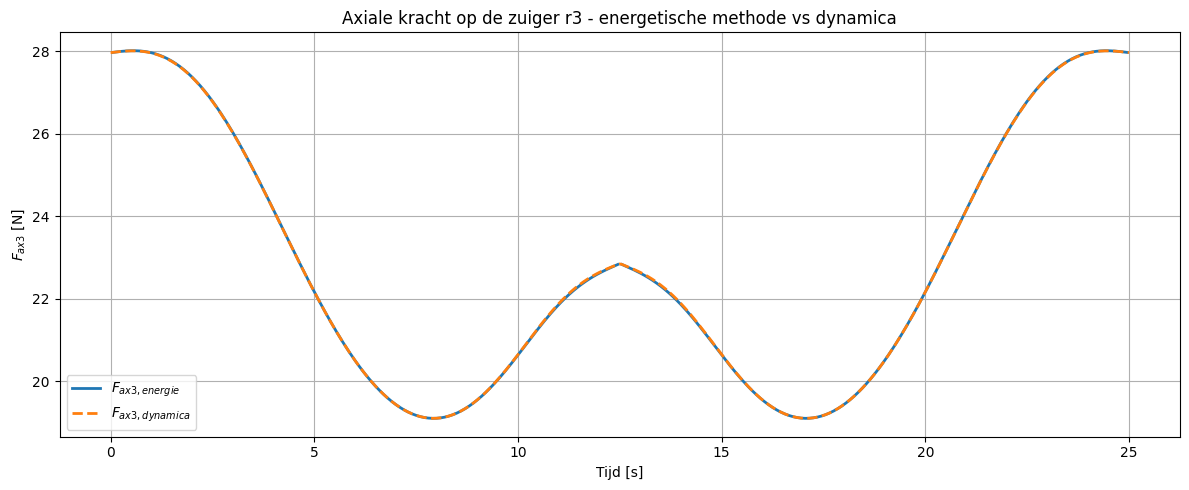

In [22]:
# ==========================================================
# AXIALE KRACHT F_ax3 VIA ENERGETISCHE METHODE
# ==========================================================

bars = [
    (bar_AK,    dphi2,  ddphi2),
    (bar_CDE,   dphi4,  ddphi4),
    (bar_KM11D, dphi11, ddphi11),
    (bar_M11JI, dphi11, ddphi11),  # r9 stijf met r11
    (bar_EF,    dphi5,  ddphi5),
    (bar_JFG,   dphi6,  ddphi6),
    (bar_IH,    dphi8,  ddphi8),
    (bar_GH,    dphi7,  ddphi7)
]

P_kin = np.zeros(N)
P_pot = np.zeros(N)

for bar, omega, alpha in bars:

    vx = bar.velocity[0, :]
    vy = bar.velocity[1, :]

    ax = bar.acceleration[0, :]
    ay = bar.acceleration[1, :]

    # dE_kin/dt = m*(vx*ax + vy*ay) + I*omega*alpha
    P_kin += (
        bar.mass * (vx*ax + vy*ay)
        + bar.inertia * omega * alpha
    )

    # dE_pot/dt = m*g*vy
    P_pot += bar.mass * g * vy

P_tot = P_kin + P_pot

# door nul delen vermijden wanneer dr3 = 0
eps = 1e-9
F_ax3_energy = np.full(N, np.nan)

mask = np.abs(dr3) > eps
F_ax3_energy[mask] = P_tot[mask] / dr3[mask]

# ==========================================================
# PLOT VERGELIJKING
# ==========================================================

plt.figure(figsize=(12,5))

plt.plot(t, F_ax3_energy, linewidth=2, label=r"$F_{ax3, energie}$")
plt.plot(t, F_ax3, "--", linewidth=2, label=r"$F_{ax3, dynamica}$")

plt.xlabel("Tijd [s]")
plt.ylabel(r"$F_{ax3}$ [N]")

plt.title("Axiale kracht op de zuiger r3 - energetische methode vs dynamica")

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()


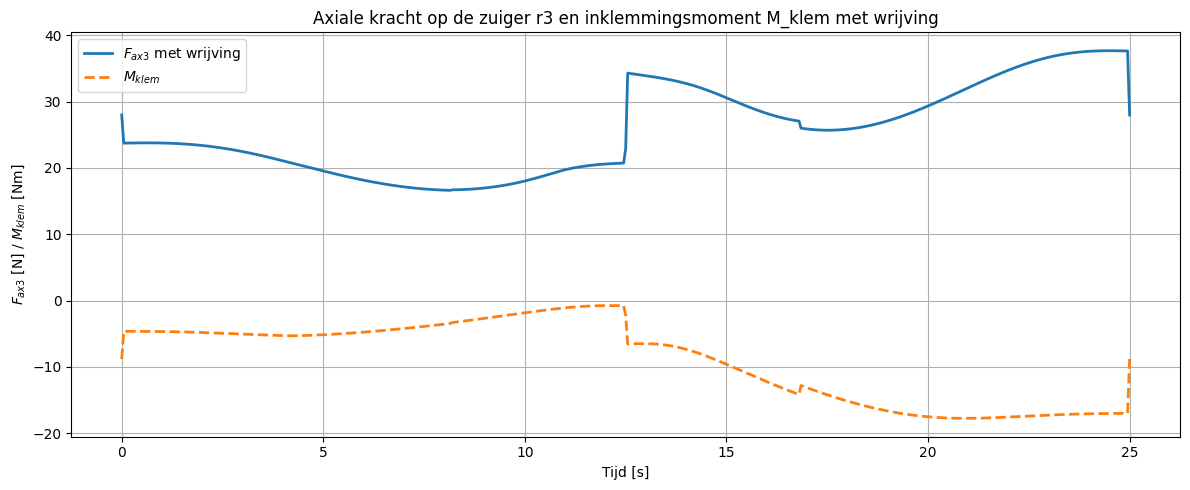

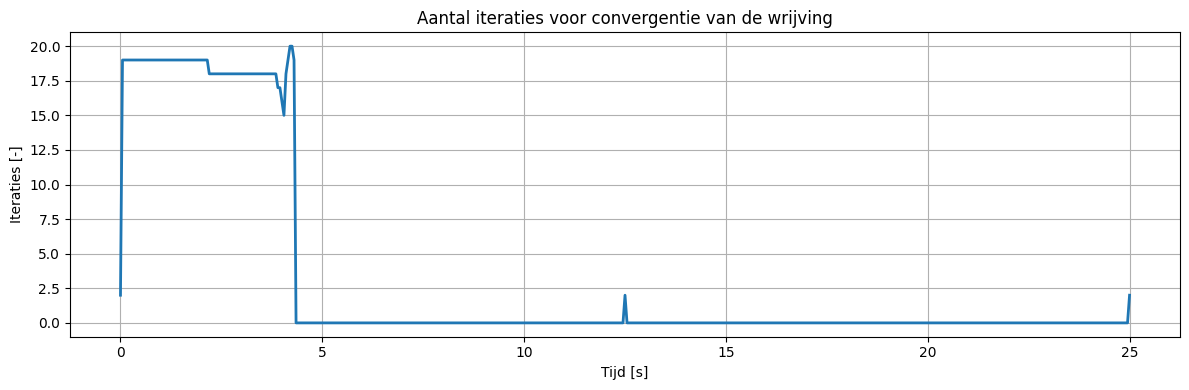

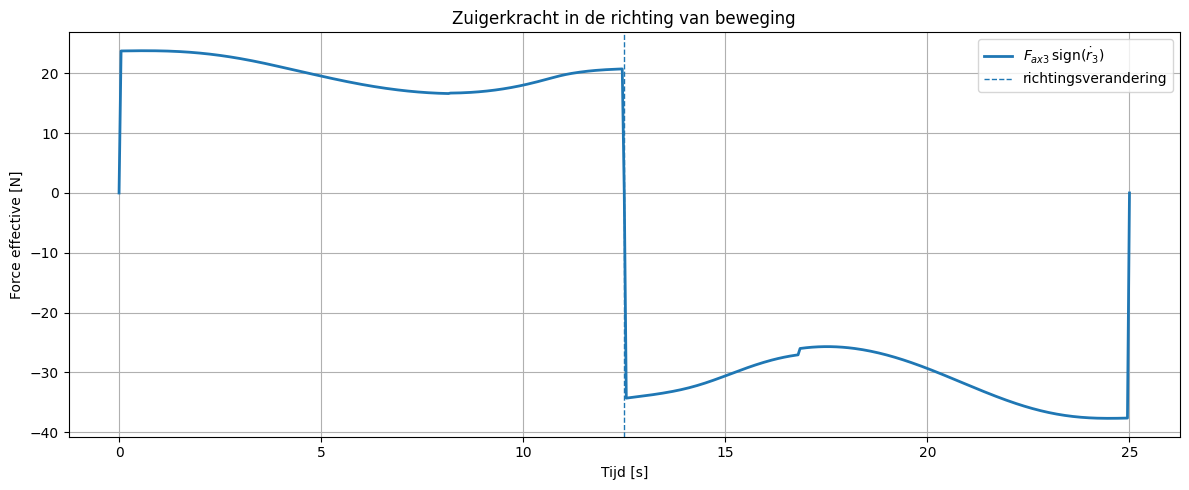

In [24]:
# ==========================================================
# DYNAMICA MET INKLEMMINGSMOMENT + WRIJVING IN DE GEWRICHTEN
# ==========================================================

def add_force_moment(A_mat, row, var, Fx_coef, Fy_coef, phi, s, idx):
    cx, cy = moment_coeffs(phi, s)
    A_mat[row, idx[var]] += cx*Fx_coef + cy*Fy_coef


# ----------------------------------------------------------
# Parameters voor wrijving 
# ----------------------------------------------------------

mu_joint = 0.50      # wrijvingscoefficient 
r_pin = 0.05        # equivalente straal van de pin [m]

eps_sign = 1e-8
max_friction_iter = 20
tol_friction = 1e-9


def smooth_sign(x, eps=eps_sign):
    return np.tanh(x / eps)


def reaction_norm(force_guess, idx, name_x, name_y):
    return np.sqrt(
        force_guess[idx[name_x]]**2
        + force_guess[idx[name_y]]**2
    )


def friction_moment(force_guess, idx, name_x, name_y, omega_bar, omega_other):
    """
    Wrijvingsmoment toegepast OP de beschouwde STAAF.
    Werkt relatieve rotatie omega_bar - omega_other tegen.
    """
    R = reaction_norm(force_guess, idx, name_x, name_y)
    omega_rel = omega_bar - omega_other

    return -mu_joint * r_pin * R * smooth_sign(omega_rel)


unknowns = [
    "A_x", "A_y",
    "C_x", "C_y",

    "K_x", "K_y",
    "D_x", "D_y",
    "E_x", "E_y",

    "M_x", "M_y",
    "M_klem",

    "I_x", "I_y",
    "J_x", "J_y",

    "F_x", "F_y",

    "G_x", "G_y",
    "H_x", "H_y",

    "F_ax3"
]

idx = {name: i for i, name in enumerate(unknowns)}
forces = np.zeros((N, len(unknowns)))
friction_iterations_used = np.zeros(N, dtype=int)

for k in range(N):

    force_guess = np.zeros(len(unknowns))

    for friction_iter in range(max_friction_iter):

        A_mat = np.zeros((24, len(unknowns)))
        b_vec = np.zeros(24)
        row = 0

        phi9_k = phi11[k] + phi9_offset
        ddphi9_k = ddphi11[k]

        e3x = np.cos(phi3[k])
        e3y = np.sin(phi3[k])

        # ==================================================
        # 1) STAAF AK
        # bar_AK = A -> K
        # joints : A met ground, K met KM11D
        # ==================================================

        add_force(A_mat, row, "A_x", 1, idx)
        add_force(A_mat, row, "K_x", 1, idx)
        b_vec[row] = bar_AK.mass * bar_AK.acceleration[0, k]
        row += 1

        add_force(A_mat, row, "A_y", 1, idx)
        add_force(A_mat, row, "K_y", 1, idx)
        b_vec[row] = bar_AK.mass * bar_AK.acceleration[1, k] + bar_AK.mass * g
        row += 1

        add_moment(A_mat, row, "A_x", "A_y", phi2[k],
                   -bar_AK.distance_Cog_joint(1), idx)
        add_moment(A_mat, row, "K_x", "K_y", phi2[k],
                    bar_AK.distance_Cog_joint(2), idx)

        Mfr_A_AK = friction_moment(
            force_guess, idx,
            "A_x", "A_y",
            dphi2[k], 0.0
        )

        Mfr_K_AK = friction_moment(
            force_guess, idx,
            "K_x", "K_y",
            dphi2[k], dphi11[k]
        )

        b_vec[row] = (
            bar_AK.inertia * ddphi2[k]
            - Mfr_A_AK
            - Mfr_K_AK
        )
        row += 1

        # ==================================================
        # 2) STAAF CDE
        # bar_CDE = C -> E, internal D
        # joints : C ground, D KM11D, E EF
        # ==================================================

        add_force(A_mat, row, "C_x", 1, idx)
        add_force(A_mat, row, "D_x", 1, idx)
        add_force(A_mat, row, "E_x", 1, idx)
        b_vec[row] = bar_CDE.mass * bar_CDE.acceleration[0, k]
        row += 1

        add_force(A_mat, row, "C_y", 1, idx)
        add_force(A_mat, row, "D_y", 1, idx)
        add_force(A_mat, row, "E_y", 1, idx)
        b_vec[row] = bar_CDE.mass * bar_CDE.acceleration[1, k] + bar_CDE.mass * g
        row += 1

        add_moment(A_mat, row, "C_x", "C_y", phi4[k],
                   -bar_CDE.distance_Cog_joint(1), idx)
        add_moment(A_mat, row, "D_x", "D_y", phi4[k],
                    bar_CDE.distance_Cog_intern_joint, idx)
        add_moment(A_mat, row, "E_x", "E_y", phi4[k],
                    bar_CDE.distance_Cog_joint(2), idx)

        Mfr_C_CDE = friction_moment(
            force_guess, idx,
            "C_x", "C_y",
            dphi4[k], 0.0
        )

        Mfr_D_CDE = friction_moment(
            force_guess, idx,
            "D_x", "D_y",
            dphi4[k], dphi11[k]
        )

        Mfr_E_CDE = friction_moment(
            force_guess, idx,
            "E_x", "E_y",
            dphi4[k], dphi5[k]
        )

        b_vec[row] = (
            bar_CDE.inertia * ddphi4[k]
            - Mfr_C_CDE
            - Mfr_D_CDE
            - Mfr_E_CDE
        )
        row += 1

        # ==================================================
        # 3) STAAF KM11D
        # bar_KM11D = K -> D, internal M11
        # joints : K AK, D CDE, M11 M11JI ingeklemd
        # moment +M_klem
        # ==================================================

        add_force(A_mat, row, "K_x", -1, idx)
        add_force(A_mat, row, "D_x", -1, idx)
        add_force(A_mat, row, "M_x",  1, idx)
        b_vec[row] = bar_KM11D.mass * bar_KM11D.acceleration[0, k]
        row += 1

        add_force(A_mat, row, "K_y", -1, idx)
        add_force(A_mat, row, "D_y", -1, idx)
        add_force(A_mat, row, "M_y",  1, idx)
        b_vec[row] = bar_KM11D.mass * bar_KM11D.acceleration[1, k] + bar_KM11D.mass * g
        row += 1

        add_moment(A_mat, row, "K_x", "K_y", phi11[k],
                   -bar_KM11D.distance_Cog_joint(1), idx, coef=-1)
        add_moment(A_mat, row, "M_x", "M_y", phi11[k],
                    bar_KM11D.distance_Cog_intern_joint, idx)
        add_moment(A_mat, row, "D_x", "D_y", phi11[k],
                    bar_KM11D.distance_Cog_joint(2), idx, coef=-1)

        add_force(A_mat, row, "M_klem", 1, idx)

        Mfr_K_KM11D = friction_moment(
            force_guess, idx,
            "K_x", "K_y",
            dphi11[k], dphi2[k]
        )

        Mfr_D_KM11D = friction_moment(
            force_guess, idx,
            "D_x", "D_y",
            dphi11[k], dphi4[k]
        )

        b_vec[row] = (
            bar_KM11D.inertia * ddphi11[k]
            - Mfr_K_KM11D
            - Mfr_D_KM11D
        )
        row += 1

        # ==================================================
        # 4) STAAF M11JI
        # bar_M11JI = M11 -> I, internal J
        # joints : M11 KM11D ingeklemd, J JFG, I IH
        # moment -M_klem
        # ==================================================

        add_force(A_mat, row, "M_x", -1, idx)
        add_force(A_mat, row, "J_x",  1, idx)
        add_force(A_mat, row, "I_x",  1, idx)
        b_vec[row] = bar_M11JI.mass * bar_M11JI.acceleration[0, k]
        row += 1

        add_force(A_mat, row, "M_y", -1, idx)
        add_force(A_mat, row, "J_y",  1, idx)
        add_force(A_mat, row, "I_y",  1, idx)
        b_vec[row] = bar_M11JI.mass * bar_M11JI.acceleration[1, k] + bar_M11JI.mass * g
        row += 1

        add_moment(A_mat, row, "M_x", "M_y", phi9_k,
                   -bar_M11JI.distance_Cog_joint(1), idx, coef=-1)
        add_moment(A_mat, row, "J_x", "J_y", phi9_k,
                    bar_M11JI.distance_Cog_intern_joint, idx)
        add_moment(A_mat, row, "I_x", "I_y", phi9_k,
                    bar_M11JI.distance_Cog_joint(2), idx)

        add_force(A_mat, row, "M_klem", -1, idx)

        Mfr_J_M11JI = friction_moment(
            force_guess, idx,
            "J_x", "J_y",
            dphi11[k], dphi6[k]
        )

        Mfr_I_M11JI = friction_moment(
            force_guess, idx,
            "I_x", "I_y",
            dphi11[k], dphi8[k]
        )

        b_vec[row] = (
            bar_M11JI.inertia * ddphi9_k
            - Mfr_J_M11JI
            - Mfr_I_M11JI
        )
        row += 1

        # ==================================================
        # 5) STAAF EF
        # bar_EF = E -> F
        # joints : E CDE, F JFG
        # ==================================================

        add_force(A_mat, row, "E_x", -1, idx)
        add_force(A_mat, row, "F_x",  1, idx)
        b_vec[row] = bar_EF.mass * bar_EF.acceleration[0, k]
        row += 1

        add_force(A_mat, row, "E_y", -1, idx)
        add_force(A_mat, row, "F_y",  1, idx)
        b_vec[row] = bar_EF.mass * bar_EF.acceleration[1, k] + bar_EF.mass * g
        row += 1

        add_moment(A_mat, row, "E_x", "E_y", phi5[k],
                   -bar_EF.distance_Cog_joint(1), idx, coef=-1)
        add_moment(A_mat, row, "F_x", "F_y", phi5[k],
                    bar_EF.distance_Cog_joint(2), idx)

        Mfr_E_EF = friction_moment(
            force_guess, idx,
            "E_x", "E_y",
            dphi5[k], dphi4[k]
        )

        Mfr_F_EF = friction_moment(
            force_guess, idx,
            "F_x", "F_y",
            dphi5[k], dphi6[k]
        )

        b_vec[row] = (
            bar_EF.inertia * ddphi5[k]
            - Mfr_E_EF
            - Mfr_F_EF
        )
        row += 1

        # ==================================================
        # 6) STAAF JFG
        # bar_JFG = J -> G, internal F
        # joints : J M11JI, F EF, G GH
        # zuigerkracht : -F_ax3 * e3 au point F
        # ==================================================

        add_force(A_mat, row, "J_x", -1, idx)
        add_force(A_mat, row, "F_x", -1, idx)
        add_force(A_mat, row, "G_x",  1, idx)
        add_force(A_mat, row, "F_ax3", -e3x, idx)
        b_vec[row] = bar_JFG.mass * bar_JFG.acceleration[0, k]
        row += 1

        add_force(A_mat, row, "J_y", -1, idx)
        add_force(A_mat, row, "F_y", -1, idx)
        add_force(A_mat, row, "G_y",  1, idx)
        add_force(A_mat, row, "F_ax3", -e3y, idx)
        b_vec[row] = bar_JFG.mass * bar_JFG.acceleration[1, k] + bar_JFG.mass * g
        row += 1

        add_moment(A_mat, row, "J_x", "J_y", phi6[k],
                   -bar_JFG.distance_Cog_joint(1), idx, coef=-1)
        add_moment(A_mat, row, "F_x", "F_y", phi6[k],
                    bar_JFG.distance_Cog_intern_joint, idx, coef=-1)

        add_force_moment(
            A_mat, row,
            "F_ax3",
            -e3x, -e3y,
            phi6[k],
            bar_JFG.distance_Cog_intern_joint,
            idx
        )

        add_moment(A_mat, row, "G_x", "G_y", phi6[k],
                    bar_JFG.distance_Cog_joint(2), idx)

        Mfr_J_JFG = friction_moment(
            force_guess, idx,
            "J_x", "J_y",
            dphi6[k], dphi11[k]
        )

        Mfr_F_JFG = friction_moment(
            force_guess, idx,
            "F_x", "F_y",
            dphi6[k], dphi5[k]
        )

        Mfr_G_JFG = friction_moment(
            force_guess, idx,
            "G_x", "G_y",
            dphi6[k], dphi7[k]
        )

        b_vec[row] = (
            bar_JFG.inertia * ddphi6[k]
            - Mfr_J_JFG
            - Mfr_F_JFG
            - Mfr_G_JFG
        )
        row += 1

        # ==================================================
        # 7) STAAF IH
        # bar_IH = I -> H
        # joints : I M11JI, H GH
        # ==================================================

        add_force(A_mat, row, "I_x", -1, idx)
        add_force(A_mat, row, "H_x",  1, idx)
        b_vec[row] = bar_IH.mass * bar_IH.acceleration[0, k]
        row += 1

        add_force(A_mat, row, "I_y", -1, idx)
        add_force(A_mat, row, "H_y",  1, idx)
        b_vec[row] = bar_IH.mass * bar_IH.acceleration[1, k] + bar_IH.mass * g
        row += 1

        add_moment(A_mat, row, "I_x", "I_y", phi8[k],
                   -bar_IH.distance_Cog_joint(1), idx, coef=-1)
        add_moment(A_mat, row, "H_x", "H_y", phi8[k],
                    bar_IH.distance_Cog_joint(2), idx)

        Mfr_I_IH = friction_moment(
            force_guess, idx,
            "I_x", "I_y",
            dphi8[k], dphi11[k]
        )

        Mfr_H_IH = friction_moment(
            force_guess, idx,
            "H_x", "H_y",
            dphi8[k], dphi7[k]
        )

        b_vec[row] = (
            bar_IH.inertia * ddphi8[k]
            - Mfr_I_IH
            - Mfr_H_IH
        )
        row += 1

        # ==================================================
        # 8) STAAF GH
        # bar_GH = G -> H
        # joints : G JFG, H IH
        # ==================================================

        add_force(A_mat, row, "G_x", -1, idx)
        add_force(A_mat, row, "H_x", -1, idx)
        b_vec[row] = bar_GH.mass * bar_GH.acceleration[0, k]
        row += 1

        add_force(A_mat, row, "G_y", -1, idx)
        add_force(A_mat, row, "H_y", -1, idx)
        b_vec[row] = bar_GH.mass * bar_GH.acceleration[1, k] + bar_GH.mass * g
        row += 1

        add_moment(A_mat, row, "G_x", "G_y", phi7[k],
                   -bar_GH.distance_Cog_joint(1), idx, coef=-1)
        add_moment(A_mat, row, "H_x", "H_y", phi7[k],
                    bar_GH.distance_Cog_joint(2), idx, coef=-1)

        Mfr_G_GH = friction_moment(
            force_guess, idx,
            "G_x", "G_y",
            dphi7[k], dphi6[k]
        )

        Mfr_H_GH = friction_moment(
            force_guess, idx,
            "H_x", "H_y",
            dphi7[k], dphi8[k]
        )

        b_vec[row] = (
            bar_GH.inertia * ddphi7[k]
            - Mfr_G_GH
            - Mfr_H_GH
        )
        row += 1

        if row != 24:
            raise ValueError(f"Nombre d'équations incorrect : {row}")

        new_force_guess = np.linalg.solve(A_mat, b_vec)

        if np.linalg.norm(new_force_guess - force_guess) < tol_friction:
            force_guess = new_force_guess
            friction_iterations_used[k] = friction_iter + 1
            break

        force_guess = new_force_guess

    forces[k, :] = force_guess


# ==========================================================
# KRACHTEN EXTRAHEREN
# ==========================================================

for name in unknowns:
    globals()[name] = forces[:, idx[name]]


# ==========================================================
# PLOT F_ax3 MET WRIJVING
# ==========================================================

plt.figure(figsize=(12, 5))

plt.plot(t, F_ax3, linewidth=2, label=r"$F_{ax3}$ met wrijving")
plt.plot(t, M_klem, "--", linewidth=2, label=r"$M_{klem}$")

plt.xlabel("Tijd [s]")
plt.ylabel(r"$F_{ax3}$ [N] / $M_{klem}$ [Nm]")

plt.title("Axiale kracht op de zuiger r3 en inklemmingsmoment M_klem met wrijving")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ==========================================================
# PLOT AANTAL ITERATIES VOOR CONVERGENTIE VAN DE WRIJVING
# ==========================================================

plt.figure(figsize=(12, 4))

plt.plot(t, friction_iterations_used, linewidth=2)

plt.xlabel("Tijd [s]")
plt.ylabel("Iteraties [-]")

plt.title("Aantal iteraties voor convergentie van de wrijving")

plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================================
# EFFECTIEVE KRACHT F_ax3 IN DE RICHTING VAN BEWEGING
# ==========================================================

F_ax3_effort = F_ax3 * np.sign(dr3)

plt.figure(figsize=(12,5))

plt.plot(t, F_ax3_effort, linewidth=2, label=r"$F_{ax3}\,\mathrm{sign}(\dot r_3)$")

plt.axvline(t[len(t)//2], linestyle="--", linewidth=1, label="richtingsverandering")

plt.xlabel("Tijd [s]")
plt.ylabel("Force effective [N]")

plt.title("Zuigerkracht in de richting van beweging")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

COMMENT: ik begrijp niet helemaal hoe het aantal iteraties over de TIJD relevant is